### Cartpole Rendering
![cartpole](cartpole.png)

In [ ]:
import gymnasium as gym
from gymnasium.wrappers.common import TimeLimit
from gymnasium.envs.classic_control.cartpole import CartPoleEnv
from gymnasium.spaces import Discrete, Box
import typing as t
from collections import deque
from numpy.typing import NDArray
import random

In [5]:
import torch
from collections import deque

import numpy as np

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

# import gym

In [ ]:
# !pip install wandb -qqq
import wandb

wandb.login()
run = wandb.init(project="orcs4529_hw2_dqn")

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have 

## DQN (Deep Q Network)

In previous Labs, we have learned to use Pytorch to build deep learning models. In this lab, we will apply deep learning as function approximations in reinforcement learning.

Reference: DQN https://arxiv.org/abs/1312.5602

In tabular Q-learning, we maintain a table of state-action pairs $(s,a)$ and save one action value for each entry $Q(s,a),\forall (s,a)$. At each time step $t$, we are in state $s_t$, then we choose action based on $\epsilon-$greedy strategy. With prob $\epsilon$, choose action uniformly random; with prob $1-\epsilon$, choose action based on $$a_t = \arg\max_a Q(s_t,a)$$

We then get the instant reward $r_t$, update the Q-table using the following rule

$$Q(s_t,a_t) \leftarrow (1-\alpha)Q(s_t,a_t) + \alpha (r_t + \max_a \gamma Q(s_{t+1},a))$$

where $\alpha \in (0,1)$ is learning rate. The algorithm is shown to converge in tabular cases. However, in cases where we cannot keep a table for state and action, we need function approximation. Consider using neural network with parameter $\theta$, the network takes as input state $s$ and action $a$. (*there are alternative parameterizations here*). Let $Q_\theta(s,a)$ be the output of the network, to estimate the optimal action value function in state $s$ and take action $a$ (and follow optimal policy thereafter).

$$Q_\theta(s,a) \approx Q^\ast(s,a)$$

### Bellman optimality equation

We will use Bellman optimality equation to find $\theta$ such that the above approximation holds better. Recall that for optimal Q function $Q^\ast(s,a)$ the following holds for all $(s,a)$

$$Q^\ast(s_t,a_t) = \mathbb{E}\big[r_t + \gamma \max_a Q^\ast(s_{t+1},a)\big]$$

where the expectation is wrt the random reward $r_t$ and transition to the next state $s_{t+1}$. A natural objective to consider is

$$\min_\theta\  (Q_\theta(s_t,a_t) -\mathbb{E}\big[r_t + \gamma  \max_a  Q_{\hat \theta}(s_{t+1},a)\big])^2$$
at the current or previous $\hat \theta$.

### Building the DQN model

The first step is to build a neural network with parameters $\theta$ that predicts $Q_\theta(s,a)$ for any $(s,a)$. You can either build a network that

* (in case of small number $K$ of discrete actions) takes as input a  representation of state $s$ and outputs a $K$-dimensional vector giving scores $Q(s,a), a=1,\ldots, K$ for all actions

or

* takes as input a concatenated representation of state and action $(s,a)$ and output one dimensional score $Q_\theta(s,a)$,

Below we have provided a skeleton code (incomplete) for defining and training the Q-function. **You need to fill in the DNN model definition and loss function definition**. Refer to regression lab (lab 2) for help.

In [ ]:
# define neural net Q_\theta(s,a) as a class
import torch
import numpy as np


class Qfunction:
    obssize: int
    actsize: int
    h1: int
    h2: int
    model: torch.nn.Sequential
    optimizer: torch.optim.Optimizer

    def __init__(self, obssize: int, actsize: int | np.signedinteger, lr: float):
        """
        obssize: dimension of state space
        actsize: dimension of action space
        sess: sess to execute this Qfunction
        optimizer:
        """
        # RECORD HYPER-PARAMS
        self.obssize = obssize
        self.actsize = int(actsize)

        self.h1 = min(512, max(64, 2 * obssize))
        self.h2 = min(512, max(64, int(obssize + actsize)))

        # DEFINE THE MODEL
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.obssize, self.h1),
            torch.nn.ReLU(),
            torch.nn.Linear(self.h1, self.h2),
            torch.nn.ReLU(),
            torch.nn.Linear(self.h2, self.actsize),  # outputs Q(s,a) for all a
        )

        # DEFINE THE OPTIMIZER
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def _to_one_hot(self, y: torch.Tensor, num_classes: int):
        """
        convert an integer vector y into one-hot representation
        """
        scatter_dim = len(y.size())
        y_tensor = y.view(*y.size(), -1)
        zeros = torch.zeros(*y.size(), num_classes, dtype=y.dtype)
        return zeros.scatter(scatter_dim, y_tensor, 1)

    def compute_Qvalues(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        """
        input: list of numsamples state-action pairs
        output: List of Q values for each input (s,a). The output will have size [numsamples, 1]
        """
        # Below is example code when neural network is set to take as input state and output Q-value for all actions.
        # This will be different for neural network that takes as input a state-action pair

        states = states.float().view(-1, self.obssize)  # (N, 4)
        actions = actions.view(-1, 1).long()  # (N, 1)
        q_all: torch.Tensor = self.model(states)  # (N, 2)
        return q_all.gather(1, actions).squeeze(1)

    def compute_maxQvalues(self, states: torch.Tensor | np.ndarray) -> torch.Tensor:
        """
        input: a list of numsamples states
        output: max_a Q(s,a) values for every input state s in states. The output will have size numsamples
        """
        # Below is example code when neural network is set to take as input state and output Q-value for all actions.
        # if the neural takes as input a state-action pair, then the code will need to loop over all actions to compute all values
        states = torch.from_numpy(states) if isinstance(states, np.ndarray) else states
        states = states.float().view(-1, self.obssize)  # <— force (N, 4)
        q_all: torch.Tensor = self.model(states)  # (N, actsize)
        return torch.max(q_all, dim=1).values

    def compute_argmaxQ(self, state: np.ndarray | torch.Tensor, epsilon: float | np.float32 = 0):
        """
        input:
            state: (obssize,) or (1, obssize)
        output:
            greedy action index as np.int64
        """
        st = torch.from_numpy(state).float() if isinstance(state, np.ndarray) else state.float()

        if st.dim() == 1:
            st = st.unsqueeze(0)  # (1, S)

        if np.random.rand() < epsilon:
            a = np.random.randint(self.actsize)
        else:
            q: torch.Tensor = self.model(st)  # (1, A)
            a: int = int(torch.argmax(q, dim=1).item())

        return a

    def train(
        self,
        states: np.ndarray | torch.Tensor,
        actions: np.ndarray | torch.Tensor,
        targets: np.ndarray | torch.Tensor,
    ):
        """
        states: numpy array as input to compute loss (s)
        actions: numpy array as input to compute loss (a)
        targets: numpy array as input to compute loss (Q targets)
        """
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        targets = torch.FloatTensor(targets)

        # COMPUTE Q PREDICTIONS for all state-action pairs
        q_preds_selected = self.compute_Qvalues(states, actions)

        # LOSS
        # print(q_preds_selected.shape, targets.shape)
        loss = torch.mean((q_preds_selected - targets) ** 2)

        # BACKWARD PASS
        self.optimizer.zero_grad()
        loss.backward()

        # UPDATE
        self.optimizer.step()

        return loss.detach().cpu().data.numpy()

At this point you can skip ahead to implementing the basic Q-learning that at every step $t$ in the environment
* given state $s_t$, computes greedy actions from Q-values (using compute_argmaxQ function above) and uses $\epsilon$-greedy select an action $a_t$,
* makes observation of reward $r_t$ and next state $s_{t+1}$
* using compute_maxQvalues() function, computes target
  $$r_t + \gamma \max_a Q_\theta(s_{t+1},a)$$
and then retrains the Q-function using train() function above (with numsamples=1)

However, for improved performance you may want to consider ideas like batch training (numsamples>1 is the batch size) with experience replay buffer and target-networks.

**Replay Buffer**

Maintain a buffer $R$ to store trainsition tuples $(s_t,a_t,r_t,s_{t+1})$, when we minimize the Bellman error. When optimizing the Bellman error loss, we sample batches from the replay buffer and compute gradients for update on these batches. In particular, in each update, we sample $N$ tuples from buffer $(s_i,a_i,r_i,s_{i}') \sim R$ and then compute
targets

$$d_i=r_i + \max_a \gamma Q_{\theta}(s_i^\prime,a)$$
for all $i$. Use the above training function train() with input as list $(s_i, a_i, d_i)_{i=1}^N$  to update parameters using backprop.

**Target Network**

Maintain a target network in addition to the original pricipal network. The target network is just a copy of the original network but the parameters are not updated by gradients. The target network $\theta^-$ is copied from the principal network every $\tau$ time steps. Target network is used to compute the targets for update

$$d_i =  r_t + \gamma \max_a Q_{\theta^{-}}(s_{i}^\prime,a)$$

the targets are used in the loss function to update the principal network parameters. This slowly updated target network ensures that the targets come from a relatively stationary distribution and hence stabilize learning.

Hence several critical parts of the complete pseudocode for DQN is as follows:

**Initialization.**
principal network $Q_\theta(s,a)$, target network $Q_{\theta^{-}}(s,a)$. Replay buffer $R = \{\}$ (empty).

**At each time step $t.$**
The agent executes action using $\epsilon-$greedy based on the principal network $Q_\theta(s,a)$. To update $\theta$: sample $N$ tuples $(s_i,a_i,r_i,s_i^\prime) \sim R$, compute empirical loss

$$\frac{1}{N} \sum_{i=1}^N (Q_\theta(s_i,a_i) - (r_i + \gamma \max_a Q_{\theta^{-}}(s_i^\prime,a))^2$$

and update parameter $\theta$ using backprop (just take one gradient step).

**Update target network.**
Every $\tau$ time steps, update target network by copying $\theta_{\text{target}} \leftarrow \theta$.

**Bellman target.**
Above, we have defined the target values as being computed from a target net with parameter $\theta^-$
$$r_i + \gamma \max_a Q_{\theta^{-}}(s_i^\prime,a)$$
It is worth thinking about what happens if we are at the end of an episode, that is, what if $s_i^\prime$ here is a terminal state. In this case, should the Bellman error be defined exactly the same as above? Do we need some modifications? Think carefully about this as this will greatly impact the algorithmic performance.

### Implementation of replay buffer

In [ ]:
from functools import cache
from typing import SupportsFloat
import numpy as np
import typing as t
from collections import deque
from numpy.typing import NDArray


@cache
def get_weights(size: int, decay_denom: int):
    x = np.arange(1, size + 1)
    unweighted = np.exp((x - size) / decay_denom)
    return unweighted


Transition = tuple[
    np.ndarray,
    int | np.signedinteger,
    float | SupportsFloat,
    t.Literal[0, 1],
    np.ndarray,
]


class ReplayBuffer(deque[Transition]):
    x: NDArray[np.int_]
    idxs_last: NDArray[np.int_]  # indexes of last sampled batch

    def __init__(self, maxlen: int):
        super().__init__(maxlen=maxlen)

    def _sample_idxs(self, batch_size: int, decay_denom: int | None = None):
        unweighted = get_weights(self.maxlen, decay_denom or self.maxlen)[0 : len(self)]
        weights = unweighted / np.sum(unweighted)

        batch_size = min(batch_size, len(self))
        self.idxs_last = np.random.choice(len(self), batch_size, replace=False, p=weights)

    def sample_batch(self, batch_size: int, decay_denom: int | None = None):
        """
        Return a minibatch in the exact format the training loop expects:
            states:   (N, S) float32
            actions:  (N,)   int64
            rewards:  (N,)   float32
            newstates:(N, S) float32
            dones:    (N,)   float32  (0.0 or 1.0)

        NOTE: Transition is (state, action, reward, done, next_state).
        """
        self._sample_idxs(batch_size, decay_denom)

        # Unpack in the SAME order as Transition:
        # (s, a, r, d, s2) — not (s, a, r, s2, d)
        s, a, r, d, s2 = zip(*(self[i] for i in self.idxs_last))

        def _vec(x: np.ndarray) -> np.ndarray:
            # coerce each state to shape (S,) float32
            return np.asarray(x, dtype=np.float32).reshape(-1)

        states = np.stack([_vec(si) for si in s])  # (N, S)
        newstates = np.stack([_vec(s2i) for s2i in s2])  # (N, S)
        actions = np.asarray(a, dtype=np.int64).reshape(-1)
        rewards = np.asarray(r, dtype=np.float32).reshape(-1)
        dones = np.asarray(d, dtype=np.float32).reshape(-1)  # 0.0 or 1.0

        return states, actions, rewards, newstates, dones

    def sample_batch_deprecated(self, batch_size: int, decay_denom: int | None = None):
        self._sample_idxs(batch_size, decay_denom)

        # return [self[i] for i in idxs]
        s, a, r, s2, d = zip(*(self[i] for i in self.idxs_last))
        return (
            np.stack(s),
            np.asarray(a),
            np.asarray(r, dtype=np.float32),
            np.stack(s2),
            np.asarray(d, dtype=np.bool_),
        )

### Code snippet for copying target network
You may use th following to update target network i.e. to copy from principal network to target network. We need to use tensorflow scope to distinguish the computational graphs of target and principal networks. The following function builds a tensorflow operation that does the copying $\theta^- \leftarrow \theta$

In [9]:
def run_target_update(Qprincipal: Qfunction, Qtarget: Qfunction):
    for v, v_ in zip(Qprincipal.model.parameters(), Qtarget.model.parameters()):
        v_.data.copy_(v.data)

## Main code for DQN
Now that we have all the ingredients for DQN, we can write the main procedure to train DQN on a given environment. The implementation is straightforward if you follow the pseudocode pdf.

In [10]:
envname = "CartPole-v0"  # environment name
max_episode_steps = 200  # max number of steps per episode
env = t.cast(CartPoleEnv, gym.make(envname, max_episode_steps=max_episode_steps))
type(env)

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


gymnasium.wrappers.common.TimeLimit

## Loop


In [11]:
# hyper-parameters
lr = 1e-3  # learning rate for gradient update
batchsize = 64  # batchsize for buffer sampling
maxlength = 1000  # max number of tuples held by buffer
tau = 100  # time steps for target update
episodes = 3000  # number of episodes to run
initialsize = 500  # initial time steps before start training
trainfreq = 20  # frequency of training steps
epsilon_init = 0.5  # constant for exploration
gamma = 0.99  # discount

obssize = t.cast(Box, env.observation_space).low.size
actsize = t.cast(Discrete, env.action_space).n

In [12]:
Qprincipal = Qfunction(obssize, actsize, lr)
Qtarget = Qfunction(obssize, actsize, lr)

# initialization of graph and buffer
buffer = ReplayBuffer(maxlength)

In [13]:
rrecord = []  # record of episode rewards
totalstep = 0  # total number of steps taken
print_debug = False  # flag for printing debug information

In [ ]:
import tqdm
from math import ceil, log

In [ ]:
@cache
def _exp_decay(required_len: int, initial_epsilon: float = 0.95, half_life: float = 1000, min_value: float = 0.01):
    t = np.arange(required_len)
    decay = np.exp(-np.log(2.0) * t / half_life)  # exp with half-life semantics
    arr = np.maximum(min_value, initial_epsilon * decay).astype(np.float32)
    return arr


def exp_decay(episode: int, initial_epsilon: float = 0.95, half_life: float = 1000.0, min_value: float = 0.01):
    eff_episode = 2 ** (ceil(log(episode + 1, 2)))
    arr = _exp_decay(eff_episode, initial_epsilon, half_life, min_value)

    return arr[episode]

In [ ]:
for episode in tqdm.tqdm(range(episodes)):

    obs, info = env.reset()
    done = False
    rsum = 0

    while not done:
        # greedy choice below. Use epsilon greedy for exploration
        epsilon = exp_decay(episode, epsilon_init, half_life=500)
        action = Qprincipal.compute_argmaxQ(np.expand_dims(obs, 0), epsilon=epsilon)

        newobs, r, done, trunc, info = env.step(action)
        done_ = 1 if done else 0
        e = (obs, action, r, done_, newobs)

        # IF NOT USING BUFFER:
        # use single sample (obs, action, r, done_, newobs) with Qtarget to compute target and train Qprincipal

        # ELSE IF USING REPLAY BUFFER
        # append experiences e to buffer
        buffer.append(e)

        # every few episodes (decide the frequency) sample a minibatch from buffer
        # compute targets in batch using Qtarget and train Qprincipal
        if totalstep > initialsize and totalstep % trainfreq == 0:
            # sample a minibatch
            states, actions, rewards, newstates, dones = buffer.sample_batch(batchsize, decay_denom=maxlength)

            qnews = Qtarget.compute_maxQvalues(newstates).detach().view(-1)

            # Bellman targets: d = r + γ * (1 - done) * max_a Q_target(s', a)
            targets_t = rewards + gamma * (1.0 - dones) * qnews.numpy()

            loss = Qprincipal.train(states, actions, targets_t)

        # UPDATE target network
        # every tau steps update copy the principal network to the target network
        if totalstep % tau == 0:
            run_target_update(Qprincipal, Qtarget)

        # update
        totalstep += 1
        rsum += r  # type: ignore
        obs = newobs
        done = done or rsum > max_episode_steps  # to avoid truncation issues

    # The code below is for printing and debugging at the end of episode

    rrecord.append(rsum)

    # printing functions for debugging purposes. Feel free to add more
    if print_debug and episode % 10 == 0:
        print("buffersize {}".format(len(buffer)))
        print("episode {} ave training returns {}".format(episode, np.mean(rrecord[-10:])))

    # printing moving averages for smoothed visualization.
    fixedWindow = 100
    movingAverage = 0
    if len(rrecord) >= fixedWindow:
        movingAverage = np.mean(rrecord[len(rrecord) - fixedWindow : len(rrecord) - 1])
    wandb.log({"training reward": rsum, "train reward moving average": movingAverage})

100%|██████████| 3000/3000 [00:35<00:00, 84.68it/s] 


## Exploration


In [15]:
states, actions, rewards, newstates, dones = buffer.sample_batch(10, decay_denom=maxlength)

In [ ]:
import pandas as pd

In [16]:
states_df = pd.DataFrame(states)
states_df.columns = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Angular Velocity",
]
newstates_df = pd.DataFrame(newstates)
newstates_df.columns = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Angular Velocity",
]

In [17]:
# compute max_a Q(s', a) with the TARGET net; ensure it's 1-D (N,)
qnews = Qtarget.compute_maxQvalues(newstates).detach().view(-1)

In [18]:
# Bellman targets: d = r + γ * (1 - done) * max_a Q_target(s', a)
targets_t = rewards + gamma * (1.0 - dones) * qnews.detach().numpy()

In [19]:
loss = Qprincipal.train(states, actions, targets_t)

In [ ]:
# dtt(
#     states_df,
#     actions,
#     rewards,
#     newstates_df,
#     dones,
#     qnews,
#     targets_t,
#     # loss,
#     names=[
#         "states",
#         "actions",
#         "rewards",
#         "newstates",
#         "dones",
#         "qnews",
#         "targets",
#         "loss",
#     ],
# )

,Cart Position,Cart Velocity,Pole Angle,Pole Angular Velocity
0,-0.092188,-0.005493,0.009529,-0.096939
1,-0.087993,-0.341204,0.019657,0.246641
2,-0.188753,0.004556,-0.004753,-0.287517
3,-0.425677,-0.335240,-0.022208,0.115076
4,-0.147441,-0.004329,0.002152,-0.122608
5,-0.968214,-0.378187,0.002993,-0.131276
6,-0.139129,-0.386528,-0.004054,0.316381
7,-0.154440,0.003740,-0.002189,-0.269526
8,-0.344143,0.007180,-0.008583,-0.345409
9,-1.215191,-0.735088,0.000159,-0.017783


In [21]:
loss

array(0.2997759, dtype=float32)

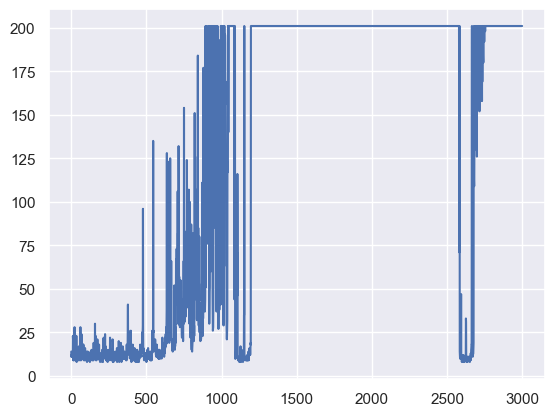

In [22]:
x = np.arange(len(rrecord))
plt.plot(x, rrecord)

In [31]:
rrecord[-1]

201.0

Finally, we evaluate the performance of the trained agent. We will evaluate the performance of the greedy policy wrt learned Q-function. The evaluation will be run 10 times, each for eval_epsiodes and print out the average performance across these episodes. Please **do not** change the code below.

In [25]:
### DO NOT CHANGE
def evaluate(Q: Qfunction, env: TimeLimit, episodes: int):
    # main iteration
    score = 0.0
    for episode in range(episodes):

        obs, info = env.reset()
        done = False
        rsum = 0

        while not done:
            # always greedy
            action = Q.compute_argmaxQ(np.expand_dims(obs, 0))

            # mdp stepping forward
            newobs, r, done, _, info = env.step(action)

            # update data
            rsum += r  # type:ignore
            obs = newobs

        wandb.log({"eval reward": rsum})
        score = score + rsum
    score = score / episodes

    return score

In [26]:
# DO NOT CHANGE CODE HERE
# after training, we will evaluate the performance of the agent
# on a target environment
env_test = gym.make(envname)
eval_episodes = 1000
score = evaluate(Qprincipal, env_test, eval_episodes)
wandb.run.summary["score"] = score

print("eval performance of DQN agent: {}".format(score))

eval performance of DQN agent: 252.934


In [27]:
score

252.934

In [28]:
run.finish()

eval reward,▃▃▄▂▄▁▄▂▂▃▁▅▂▃▃▄▅▂▂▁▇▂▃▆▁▃▆▁▄▄▃█▄▁▃▄▂▂▂▄
train reward moving average,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▅▂▂▅████████████████▄▄▂██
training reward,▁▁▁▁▁▁▂▁▁▂▂▅█████████████████████▁▁▆████
eval reward,247
score,252.934
train reward moving average,201
training reward,201
